In [1]:
import pandas as pd
import numpy as np
import seaborn as sns


In [2]:
df = pd.read_csv('/hpc/projects/mass_spec/eileenwang/TTopt/FP/HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_18p6m200nlv28_DDA95ms1500Vnopoly_TT0000266_B_A11_1_14669_speclib_autorefRT/library.tsv',
                 sep='\t')

In [35]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors
def subdivide_interleaved_cycles(df, x_col, y_col, n_cycles, bins_per_cycle=2, max_mz_window_size=None, exclude_top_im_amount=0.0):
    """
    Subdivide a 2D distribution into cycles with interleaved m/z bin assignment.
    
    For n_cycles=8 and bins_per_cycle=2:
    - Cycle 1 gets m/z bins 1 and 9
    - Cycle 2 gets m/z bins 2 and 10  
    - Cycle 3 gets m/z bins 3 and 11
    - etc.
    
    Within each cycle, bins have non-overlapping IM ranges.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data points
    x_col : str
        Column name for m/z values
    y_col : str
        Column name for IM values
    n_cycles : int
        Number of cycles
    bins_per_cycle : int
        Number of bins per cycle (default 2)
    max_mz_window_size : float, optional
        Maximum allowed width for any m/z bin. If specified, bins exceeding
        this width will be subdivided further (default: None, no limit)
    exclude_top_im_amount : float, optional
        Fixed IM amount to exclude from the top of each bin (in IM units).
        This creates a dead zone at the high end of each bin where no precursors
        are detected (default: 0.0, no exclusion)
        
    Returns:
    --------
    dict
        Contains cycles and bin information with IM ranges
    """
    
    total_mz_bins = n_cycles * bins_per_cycle
    
    # Step 1: Create equal-density m/z bins accounting for exclusion zones
    def find_optimal_mz_splits_with_exclusion(data, n_splits, exclude_top_im_amount):
        """Find m/z splits that balance detectable point counts across all m/z bins"""
        x_vals = data[x_col].values
        y_vals = data[y_col].values
        
        # If exclusion is specified, filter out points that would be in exclusion zones
        if exclude_top_im_amount > 0:
            # For initial estimation, assume uniform IM distribution and exclude top portion
            y_min_data, y_max_data = y_vals.min(), y_vals.max()
            # Create a rough estimate of exclusion by removing points in top IM range
            y_threshold = y_max_data - exclude_top_im_amount
            detectable_mask = y_vals <= y_threshold
            x_vals_detectable = x_vals[detectable_mask]
            print(f"Using {len(x_vals_detectable)}/{len(x_vals)} points for m/z optimization (accounting for exclusion)")
        else:
            x_vals_detectable = x_vals
        
        sorted_indices = np.argsort(x_vals_detectable)
        sorted_x = x_vals_detectable[sorted_indices]
        
        total_points = len(x_vals_detectable)
        target_per_bin = total_points // n_splits
        
        splits = []
        current_idx = 0
        
        for i in range(n_splits - 1):
            target_idx = (i + 1) * target_per_bin
            search_range = max(target_per_bin // 10, 1)
            start_search = max(current_idx + 1, target_idx - search_range)
            end_search = min(len(sorted_x) - 1, target_idx + search_range)
            
            if start_search < end_search:
                best_split_idx = np.clip(target_idx, start_search, end_search)
                split_value = sorted_x[best_split_idx]
                splits.append(split_value)
                current_idx = best_split_idx
            else:
                split_value = sorted_x[target_idx] if target_idx < len(sorted_x) else sorted_x[-1]
                splits.append(split_value)
        
        return splits
    
    # Get data range
    x_min, x_max = df[x_col].min(), df[x_col].max()
    y_min, y_max = df[y_col].min(), df[y_col].max()
    
    # Create all m/z bins first, accounting for exclusion zones
    mz_splits = find_optimal_mz_splits_with_exclusion(df, total_mz_bins, exclude_top_im_amount)
    
    # Create m/z bin boundaries
    mz_bin_bounds = []
    prev_split = x_min
    
    for i, split in enumerate(mz_splits):
        mz_bin_bounds.append((prev_split, split, i))
        prev_split = split
    mz_bin_bounds.append((prev_split, x_max, len(mz_splits)))
    
    # Apply m/z window size constraint if specified
    if max_mz_window_size is not None:
        refined_mz_bin_bounds = []
        
        for x_start, x_end, orig_idx in mz_bin_bounds:
            window_size = x_end - x_start
            
            if window_size <= max_mz_window_size:
                # Window is within limit, keep as is
                refined_mz_bin_bounds.append((x_start, x_end, len(refined_mz_bin_bounds)))
            else:
                # Window is too large, subdivide it
                num_subdivisions = int(np.ceil(window_size / max_mz_window_size))
                subdivision_size = window_size / num_subdivisions
                
                for j in range(num_subdivisions):
                    sub_start = x_start + j * subdivision_size
                    sub_end = x_start + (j + 1) * subdivision_size
                    if j == num_subdivisions - 1:  # Last subdivision gets any remainder
                        sub_end = x_end
                    refined_mz_bin_bounds.append((sub_start, sub_end, len(refined_mz_bin_bounds)))
        
        mz_bin_bounds = refined_mz_bin_bounds
        total_mz_bins = len(mz_bin_bounds)  # Update total count after subdivision

    # Step 2: Assign m/z bins to cycles in interleaved fashion
    cycles = []
    all_bins = []
    
    for cycle_id in range(n_cycles):
        # Get m/z bins for this cycle (interleaved pattern)
        cycle_mz_bins = []
        for bin_offset in range(bins_per_cycle):
            mz_bin_idx = cycle_id + bin_offset * n_cycles
            if mz_bin_idx < len(mz_bin_bounds):
                cycle_mz_bins.append((mz_bin_idx, mz_bin_bounds[mz_bin_idx]))
        
        # Collect all data points for this cycle
        cycle_data_list = []
        cycle_mz_ranges = []
        
        for mz_bin_idx, (x_start, x_end, orig_idx) in cycle_mz_bins:
            bin_mask = (df[x_col] >= x_start) & (df[x_col] <= x_end)
            bin_data = df[bin_mask]
            cycle_data_list.append((mz_bin_idx, x_start, x_end, bin_data))
            cycle_mz_ranges.append((x_start, x_end))
        
        # Combine all data points in this cycle to determine IM splits
        all_cycle_data = pd.concat([data for _, _, _, data in cycle_data_list], ignore_index=True)
        
        if len(all_cycle_data) == 0:
            continue
            
        # Step 3: Split IM range for this cycle's bins, accounting for exclusion zones
        y_vals = all_cycle_data[y_col].values
        
        # Filter out points that would be in exclusion zones for IM optimization
        if exclude_top_im_amount > 0:
            # For IM splitting, we need to consider the actual bin boundaries that will be created
            # Use all points but account for exclusion when determining splits
            y_sorted_indices = np.argsort(y_vals)
            y_sorted = y_vals[y_sorted_indices]
            
            # Adjust the splitting to account for exclusion at the top
            effective_points = []
            for y_val in y_sorted:
                # Estimate if this point would be detectable after exclusion
                # This is approximate since we don't know final bin boundaries yet
                if y_val <= y_max - exclude_top_im_amount:
                    effective_points.append(y_val)
            
            if len(effective_points) > 0:
                y_sorted_effective = np.array(effective_points)
                print(f"Cycle {cycle_id + 1}: Using {len(effective_points)}/{len(y_sorted)} points for IM optimization")
            else:
                y_sorted_effective = y_sorted  # Fallback if no effective points
        else:
            y_sorted_indices = np.argsort(y_vals)
            y_sorted_effective = y_vals[y_sorted_indices]
        
        # Split IM range into non-overlapping regions based on effective points
        points_per_im_bin = len(y_sorted_effective) // bins_per_cycle
        remainder = len(y_sorted_effective) % bins_per_cycle
        
        im_splits = []
        current_y_idx = 0
        
        for im_bin_idx in range(bins_per_cycle - 1):
            bin_size = points_per_im_bin + (1 if im_bin_idx < remainder else 0)
            current_y_idx += bin_size
            if current_y_idx < len(y_sorted_effective):
                im_splits.append(y_sorted_effective[current_y_idx])
        
        # Create bins for this cycle
        cycle_bins = []
        prev_y_split = y_min
        
        for im_bin_idx, (mz_bin_idx, x_start, x_end, mz_bin_data) in enumerate(cycle_data_list):
            # Determine IM range for this bin
            if im_bin_idx < len(im_splits):
                y_end = im_splits[im_bin_idx]
            else:
                y_end = y_max
            
            y_start = prev_y_split
            
            # Apply per-bin IM exclusion if specified, but only if bin doesn't touch top boundary
            if exclude_top_im_amount > 0 and y_end < y_max:
                y_end_effective = y_end - exclude_top_im_amount
                # Ensure effective end doesn't go below start
                y_end_effective = max(y_end_effective, y_start)
            else:
                y_end_effective = y_end
            
            # Filter points for this bin - only count those within effective IM range
            final_mask = ((mz_bin_data[x_col] >= x_start) & 
                         (mz_bin_data[x_col] <= x_end) &
                         (mz_bin_data[y_col] >= y_start) & 
                         (mz_bin_data[y_col] <= y_end_effective))
            
            final_data = mz_bin_data[final_mask]
            
            bin_info = {
                'cycle_id': cycle_id,
                'bin_id': im_bin_idx,
                'mz_bin_id': mz_bin_idx,  # Original m/z bin index
                'x_min': x_start, 'x_max': x_end,
                'y_min': y_start, 'y_max': y_end,
                'y_max_effective': y_end_effective,  # Effective max IM after exclusion
                'count': len(final_data),
                'points_idx': final_data.index.values,
                'exclude_top_im_amount': exclude_top_im_amount
            }
            
            cycle_bins.append(bin_info)
            all_bins.append(bin_info)
            prev_y_split = y_end
        
        cycle_info = {
            'cycle_id': cycle_id,
            'mz_ranges': cycle_mz_ranges,
            'total_points': sum(bin_info['count'] for bin_info in cycle_bins),
            'bins': cycle_bins
        }
        
        cycles.append(cycle_info)
    
    # Print exclusion summary if exclusion is enabled
    if exclude_top_im_amount > 0:
        print(f"Applied {exclude_top_im_amount:.3f} IM units exclusion per bin:")
        total_excluded_area = 0
        total_bin_area = 0
        total_effective_points = 0
        total_excluded_points = 0
        
        for bin_info in all_bins:
            bin_im_range = bin_info['y_max'] - bin_info['y_min']
            actual_excluded = min(exclude_top_im_amount, bin_im_range)
            bin_area = (bin_info['x_max'] - bin_info['x_min']) * bin_im_range
            excluded_area = (bin_info['x_max'] - bin_info['x_min']) * actual_excluded
            total_excluded_area += excluded_area
            total_bin_area += bin_area
            
            # Count points that would be excluded vs detected
            bin_mask = ((df[x_col] >= bin_info['x_min']) & 
                       (df[x_col] <= bin_info['x_max']) &
                       (df[y_col] >= bin_info['y_min']) & 
                       (df[y_col] <= bin_info['y_max']))
            total_points_in_bin = bin_mask.sum()
            
            excluded_points = ((df[x_col] >= bin_info['x_min']) & 
                              (df[x_col] <= bin_info['x_max']) &
                              (df[y_col] >= bin_info['y_max_effective']) & 
                              (df[y_col] <= bin_info['y_max'])).sum()
            
            total_effective_points += bin_info['count']
            total_excluded_points += excluded_points
        
        exclusion_area_percent = (total_excluded_area / total_bin_area) * 100
        exclusion_points_percent = (total_excluded_points / (total_effective_points + total_excluded_points)) * 100
        
        print(f"Total excluded area: {exclusion_area_percent:.1f}% of total bin area")
        print(f"Total excluded points: {total_excluded_points}/{total_effective_points + total_excluded_points} ({exclusion_points_percent:.1f}%)")
        print(f"Optimization accounted for exclusion zones in bin boundary placement")
    
    return {
        'cycles': cycles,
        'all_bins': all_bins,
        'n_cycles': n_cycles,
        'bins_per_cycle': bins_per_cycle,
        'total_mz_bins': total_mz_bins
    }

def plot_interleaved_cycles(df, x_col, y_col, result, figsize=(16, 12)):
    """
    Plot the interleaved cycle binning results.
    """
    cycles = result['cycles']
    all_bins = result['all_bins']
    n_cycles = result['n_cycles']
    bins_per_cycle = result['bins_per_cycle']
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    ax1, ax2, ax3, ax4 = axes.flat
    
    # Plot 1: Scatter plot with bins
    ax1.scatter(df[x_col], df[y_col], alpha=0.2, s=0.5, c='lightgray')
    
    # Color cycles differently
    cycle_colors = plt.cm.tab10(np.linspace(0, 1, n_cycles))
    im_colors = ['red', 'blue', 'green', 'orange', 'purple']  # For different IM bins
    
    for cycle in cycles:
        cycle_color = cycle_colors[cycle['cycle_id']]
        
        for bin_info in cycle['bins']:
            im_color = im_colors[bin_info['bin_id'] % len(im_colors)]
            
            # Draw rectangle for this bin
            rect = Rectangle(
                (bin_info['x_min'], bin_info['y_min']),
                bin_info['x_max'] - bin_info['x_min'],
                bin_info['y_max'] - bin_info['y_min'],
                linewidth=2, edgecolor=im_color, facecolor=cycle_color, alpha=0.3
            )
            ax1.add_patch(rect)
            
            # Draw exclusion zone if present
            if bin_info.get('exclude_top_im_amount', 0) > 0 and 'y_max_effective' in bin_info:
                exclusion_rect = Rectangle(
                    (bin_info['x_min'], bin_info['y_max_effective']),
                    bin_info['x_max'] - bin_info['x_min'],
                    bin_info['y_max'] - bin_info['y_max_effective'],
                    linewidth=1, edgecolor='red', facecolor='red', alpha=0.4,
                    linestyle='--'
                )
                ax1.add_patch(exclusion_rect)
            
            # Add text with bin info
            if bin_info['count'] > 0:
                center_x = (bin_info['x_min'] + bin_info['x_max']) / 2
                center_y = (bin_info['y_min'] + bin_info['y_max']) / 2
                ax1.text(center_x, center_y, 
                        f"C{bin_info['cycle_id']+1}B{bin_info['bin_id']+1}\\n{bin_info['count']}", 
                        ha='center', va='center', fontsize=7, 
                        bbox=dict(boxstyle="round,pad=0.1", facecolor='white', alpha=0.9))
    
    ax1.set_xlabel(x_col)
    ax1.set_ylabel(y_col)
    ax1.set_title(f'Interleaved Cycles ({n_cycles} cycles × {bins_per_cycle} bins)')
    
    # Plot 2: Points per bin
    counts = [bin_info['count'] for bin_info in all_bins]
    bin_labels = [f"C{b['cycle_id']+1}B{b['bin_id']+1}" for b in all_bins]
    colors = [cycle_colors[b['cycle_id']] for b in all_bins]
    
    ax2.bar(range(len(counts)), counts, color=colors)
    ax2.set_xlabel('Bin')
    ax2.set_ylabel('Number of Points')
    ax2.set_title('Points per Bin')
    ax2.set_xticks(range(len(bin_labels)))
    ax2.set_xticklabels(bin_labels, rotation=45)
    
    # Plot 3: M/Z bin assignment to cycles
    mz_bin_ids = [bin_info['mz_bin_id'] for bin_info in all_bins]
    cycle_ids = [bin_info['cycle_id'] for bin_info in all_bins]
    
    for i, (mz_id, cycle_id) in enumerate(zip(mz_bin_ids, cycle_ids)):
        ax3.scatter(mz_id + 1, cycle_id + 1, color=cycle_colors[cycle_id], s=100)
        ax3.text(mz_id + 1, cycle_id + 1, f'{i+1}', ha='center', va='center', 
                color='white', fontsize=8, weight='bold')
    
    ax3.set_xlabel('M/Z Bin Number')
    ax3.set_ylabel('Cycle Number')
    ax3.set_title('M/Z Bin Assignment to Cycles')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: IM ranges per cycle
    for cycle in cycles:
        cycle_id = cycle['cycle_id']
        cycle_color = cycle_colors[cycle_id]
        
        for bin_info in cycle['bins']:
            y_start = bin_info['y_min']
            y_end = bin_info['y_max']
            ax4.barh(cycle_id + 1, y_end - y_start, left=y_start, 
                    color=im_colors[bin_info['bin_id']], alpha=0.7)
            
            # Add text
            ax4.text(y_start + (y_end - y_start)/2, cycle_id + 1,
                    f"B{bin_info['bin_id']+1}", ha='center', va='center', 
                    fontsize=8, color='white', weight='bold')
    
    ax4.set_xlabel('Ion Mobility Range')
    ax4.set_ylabel('Cycle Number')
    ax4.set_title('IM Ranges per Cycle')
    
    plt.tight_layout()
    return fig, axes

In [36]:
# Example: Create 8 cycles with 2 bins each, interleaved m/z assignment
n_cycles = 8
bins_per_cycle = 2

interleaved_result = subdivide_interleaved_cycles(df, 'PrecursorMz', 'PrecursorIonMobility', n_cycles, bins_per_cycle)

print(f"Created {n_cycles} cycles with {bins_per_cycle} bins each (interleaved m/z assignment):")
print(f"Total bins: {len(interleaved_result['all_bins'])}")
print(f"Total m/z bins: {interleaved_result['total_mz_bins']}")
print()

for cycle in interleaved_result['cycles']:
    print(f"Cycle {cycle['cycle_id'] + 1}:")
    print(f"  M/Z ranges: {[(f'[{x_min:.2f}, {x_max:.2f}]') for x_min, x_max in cycle['mz_ranges']]}")
    print(f"  Total points: {cycle['total_points']}")
    
    for bin_info in cycle['bins']:
        print(f"    Bin {bin_info['bin_id'] + 1} (M/Z bin {bin_info['mz_bin_id'] + 1}):")
        print(f"      M/Z: [{bin_info['x_min']:.2f}, {bin_info['x_max']:.2f}]")
        print(f"      IM: [{bin_info['y_min']:.3f}, {bin_info['y_max']:.3f}]")
        print(f"      Points: {bin_info['count']}")
    print()

# Show the interleaved pattern
print("Interleaved M/Z Bin Assignment Pattern:")
for cycle_id in range(n_cycles):
    mz_bins_for_cycle = []
    for bin_offset in range(bins_per_cycle):
        mz_bin_idx = cycle_id + bin_offset * n_cycles + 1  # +1 for 1-based indexing
        if mz_bin_idx <= interleaved_result['total_mz_bins']:
            mz_bins_for_cycle.append(mz_bin_idx)
    print(f"Cycle {cycle_id + 1} gets M/Z bins: {mz_bins_for_cycle}")

# Statistics
all_counts = [bin_info['count'] for bin_info in interleaved_result['all_bins']]
print(f"\\nOverall Statistics:")
print(f"Mean points per bin: {np.mean(all_counts):.1f}")
print(f"Std deviation: {np.std(all_counts):.1f}")
print(f"Min: {np.min(all_counts)}, Max: {np.max(all_counts)}")

Created 8 cycles with 2 bins each (interleaved m/z assignment):
Total bins: 16
Total m/z bins: 16

Cycle 1:
  M/Z ranges: ['[305.46, 489.75]', '[788.91, 823.77]']
  Total points: 84151
    Bin 1 (M/Z bin 1):
      M/Z: [305.46, 489.75]
      IM: [0.663, 0.906]
      Points: 42063
    Bin 2 (M/Z bin 9):
      M/Z: [788.91, 823.77]
      IM: [0.906, 1.443]
      Points: 42088

Cycle 2:
  M/Z ranges: ['[489.75, 552.22]', '[823.77, 858.46]']
  Total points: 82556
    Bin 1 (M/Z bin 2):
      M/Z: [489.75, 552.22]
      IM: [0.663, 0.936]
      Points: 41280
    Bin 2 (M/Z bin 10):
      M/Z: [823.77, 858.46]
      IM: [0.936, 1.443]
      Points: 41276

Cycle 3:
  M/Z ranges: ['[552.22, 600.35]', '[858.46, 894.78]']
  Total points: 80670
    Bin 1 (M/Z bin 3):
      M/Z: [552.22, 600.35]
      IM: [0.663, 0.973]
      Points: 40334
    Bin 2 (M/Z bin 11):
      M/Z: [858.46, 894.78]
      IM: [0.973, 1.443]
      Points: 40336

Cycle 4:
  M/Z ranges: ['[600.35, 642.84]', '[894.78, 937.00]'

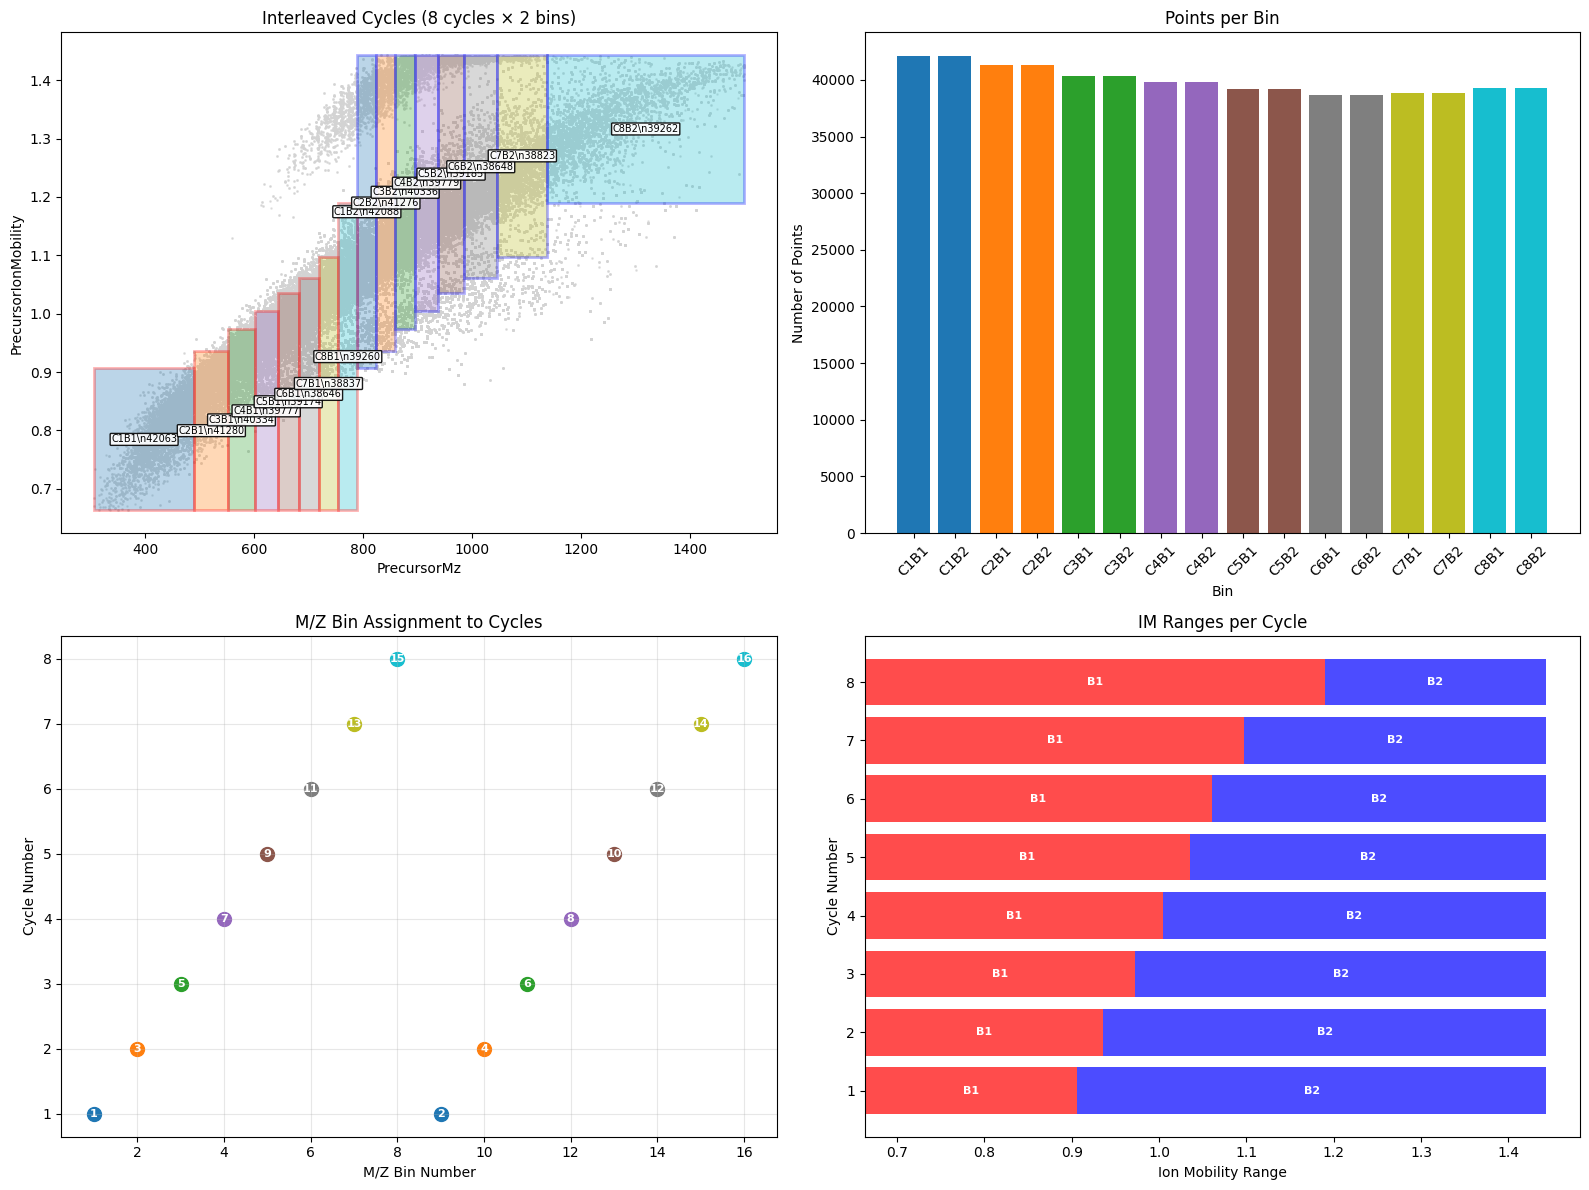

In [37]:
# Plot the interleaved cycle binning results
fig, axes = plot_interleaved_cycles(df, 'PrecursorMz', 'PrecursorIonMobility', interleaved_result)
plt.show()

In [38]:
# Look for charge-related columns
charge_columns = 'PrecursorCharge'

print(f"\n{charge_columns} value distribution:")
print(df[charge_columns].value_counts().head(10))



PrecursorCharge value distribution:
PrecursorCharge
2    477987
3    151747
1     34219
4     10381
5       374
Name: count, dtype: int64


In [39]:
def analyze_precursor_coverage_by_charge(df, result, charge_col='PrecursorCharge'):
    """
    Analyze precursor coverage by charge state for each bin and cycle.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Original dataframe with precursor data
    result : dict
        Result from subdivide_interleaved_cycles function
    charge_col : str
        Column name containing charge information
    
    Returns:
    --------
    dict
        Detailed analysis including charge distributions per bin and cycle
    """
    
    # Get unique charge states
    unique_charges = sorted(df[charge_col].unique())
    
    # Initialize results
    charge_analysis = {
        'unique_charges': unique_charges,
        'overall_distribution': df[charge_col].value_counts().sort_index(),
        'cycle_analysis': [],
        'bin_analysis': [],
        'summary_stats': {}
    }
    
    # Analyze each cycle
    for cycle_info in result['cycles']:
        cycle_id = cycle_info['cycle_id']
        cycle_charge_counts = {charge: 0 for charge in unique_charges}
        cycle_bins_detail = []
        
        # Analyze each bin in the cycle
        for bin_info in cycle_info['bins']:
            # Get points in this bin
            points_idx = bin_info['points_idx']
            bin_data = df.loc[points_idx]
            
            # Count by charge state
            bin_charge_counts = bin_data[charge_col].value_counts().reindex(unique_charges, fill_value=0)
            
            # Add to cycle totals
            for charge in unique_charges:
                cycle_charge_counts[charge] += bin_charge_counts[charge]
            
            # Store bin details
            bin_detail = {
                'cycle_id': cycle_id,
                'bin_id': bin_info['bin_id'],
                'mz_bin_id': bin_info['mz_bin_id'],
                'total_precursors': bin_info['count'],
                'charge_counts': bin_charge_counts.to_dict(),
                'charge_percentages': (bin_charge_counts / bin_charge_counts.sum() * 100).round(1).to_dict() if bin_charge_counts.sum() > 0 else {charge: 0.0 for charge in unique_charges},
                'mz_range': (bin_info['x_min'], bin_info['x_max']),
                'im_range': (bin_info['y_min'], bin_info['y_max'])
            }
            cycle_bins_detail.append(bin_detail)
            charge_analysis['bin_analysis'].append(bin_detail)
        
        # Store cycle details
        total_cycle_precursors = sum(cycle_charge_counts.values())
        cycle_detail = {
            'cycle_id': cycle_id,
            'total_precursors': total_cycle_precursors,
            'charge_counts': cycle_charge_counts,
            'charge_percentages': {charge: (count/total_cycle_precursors*100) if total_cycle_precursors > 0 else 0 
                                 for charge, count in cycle_charge_counts.items()},
            'bins': cycle_bins_detail
        }
        charge_analysis['cycle_analysis'].append(cycle_detail)
    
    # Calculate summary statistics
    total_analyzed = sum(bin_info['count'] for bin_info in result['all_bins'])
    
    # Charge state distribution across all bins
    all_bin_charge_counts = {charge: 0 for charge in unique_charges}
    for bin_detail in charge_analysis['bin_analysis']:
        for charge, count in bin_detail['charge_counts'].items():
            all_bin_charge_counts[charge] += count
    
    charge_analysis['summary_stats'] = {
        'total_precursors_analyzed': total_analyzed,
        'charge_distribution_in_bins': all_bin_charge_counts,
        'charge_coverage_percentages': {charge: (count/total_analyzed*100) if total_analyzed > 0 else 0 
                                      for charge, count in all_bin_charge_counts.items()},
        'original_vs_binned_comparison': {
            charge: {
                'original': int(charge_analysis['overall_distribution'].get(charge, 0)),
                'in_bins': all_bin_charge_counts[charge],
                'coverage_rate': (all_bin_charge_counts[charge] / charge_analysis['overall_distribution'].get(charge, 1) * 100) if charge_analysis['overall_distribution'].get(charge, 0) > 0 else 0
            }
            for charge in unique_charges
        }
    }
    
    return charge_analysis

def print_charge_analysis(charge_analysis):
    """
    Print a comprehensive report of the charge analysis.
    """
    print("PRECURSOR CHARGE ANALYSIS REPORT")
    print("=" * 60)
    
    # Summary statistics
    stats = charge_analysis['summary_stats']
    print(f"Total precursors analyzed: {stats['total_precursors_analyzed']:,}")
    print()
    
    print("Overall Charge Distribution in Bins:")
    print("-" * 40)
    for charge in charge_analysis['unique_charges']:
        count = stats['charge_distribution_in_bins'][charge]
        percentage = stats['charge_coverage_percentages'][charge]
        print(f"Charge +{charge}: {count:,} precursors ({percentage:.1f}%)")
    print()
    
    # Coverage comparison
    print("Original vs Binned Coverage:")
    print("-" * 40)
    for charge in charge_analysis['unique_charges']:
        comparison = stats['original_vs_binned_comparison'][charge]
        print(f"Charge +{charge}: {comparison['in_bins']:,}/{comparison['original']:,} ({comparison['coverage_rate']:.1f}% covered)")
    print()
    
    # Cycle-by-cycle analysis
    print("Charge Distribution by Cycle:")
    print("-" * 40)
    for cycle_info in charge_analysis['cycle_analysis']:
        cycle_id = cycle_info['cycle_id']
        total = cycle_info['total_precursors']
        print(f"Cycle {cycle_id + 1} (Total: {total:,} precursors):")
        
        for charge in charge_analysis['unique_charges']:
            count = cycle_info['charge_counts'][charge]
            percentage = cycle_info['charge_percentages'][charge]
            print(f"  Charge +{charge}: {count:,} ({percentage:.1f}%)")
        print()


# Run the charge analysis on our interleaved result
print("Running charge-based analysis on the interleaved cycle result...")
charge_analysis = analyze_precursor_coverage_by_charge(df, interleaved_result)
print_charge_analysis(charge_analysis)

Running charge-based analysis on the interleaved cycle result...
PRECURSOR CHARGE ANALYSIS REPORT
Total precursors analyzed: 638,768

Overall Charge Distribution in Bins:
----------------------------------------
Charge +1: 28,484 precursors (4.5%)
Charge +2: 466,437 precursors (73.0%)
Charge +3: 134,113 precursors (21.0%)
Charge +4: 9,366 precursors (1.5%)
Charge +5: 368 precursors (0.1%)

Original vs Binned Coverage:
----------------------------------------
Charge +1: 28,484/34,219 (83.2% covered)
Charge +2: 466,437/477,987 (97.6% covered)
Charge +3: 134,113/151,747 (88.4% covered)
Charge +4: 9,366/10,381 (90.2% covered)
Charge +5: 368/374 (98.4% covered)

Charge Distribution by Cycle:
----------------------------------------
Cycle 1 (Total: 84,151 precursors):
  Charge +1: 3,810 (4.5%)
  Charge +2: 54,582 (64.9%)
  Charge +3: 23,968 (28.5%)
  Charge +4: 1,742 (2.1%)
  Charge +5: 49 (0.1%)

Cycle 2 (Total: 82,556 precursors):
  Charge +1: 4,607 (5.6%)
  Charge +2: 55,323 (67.0%)
  Cha

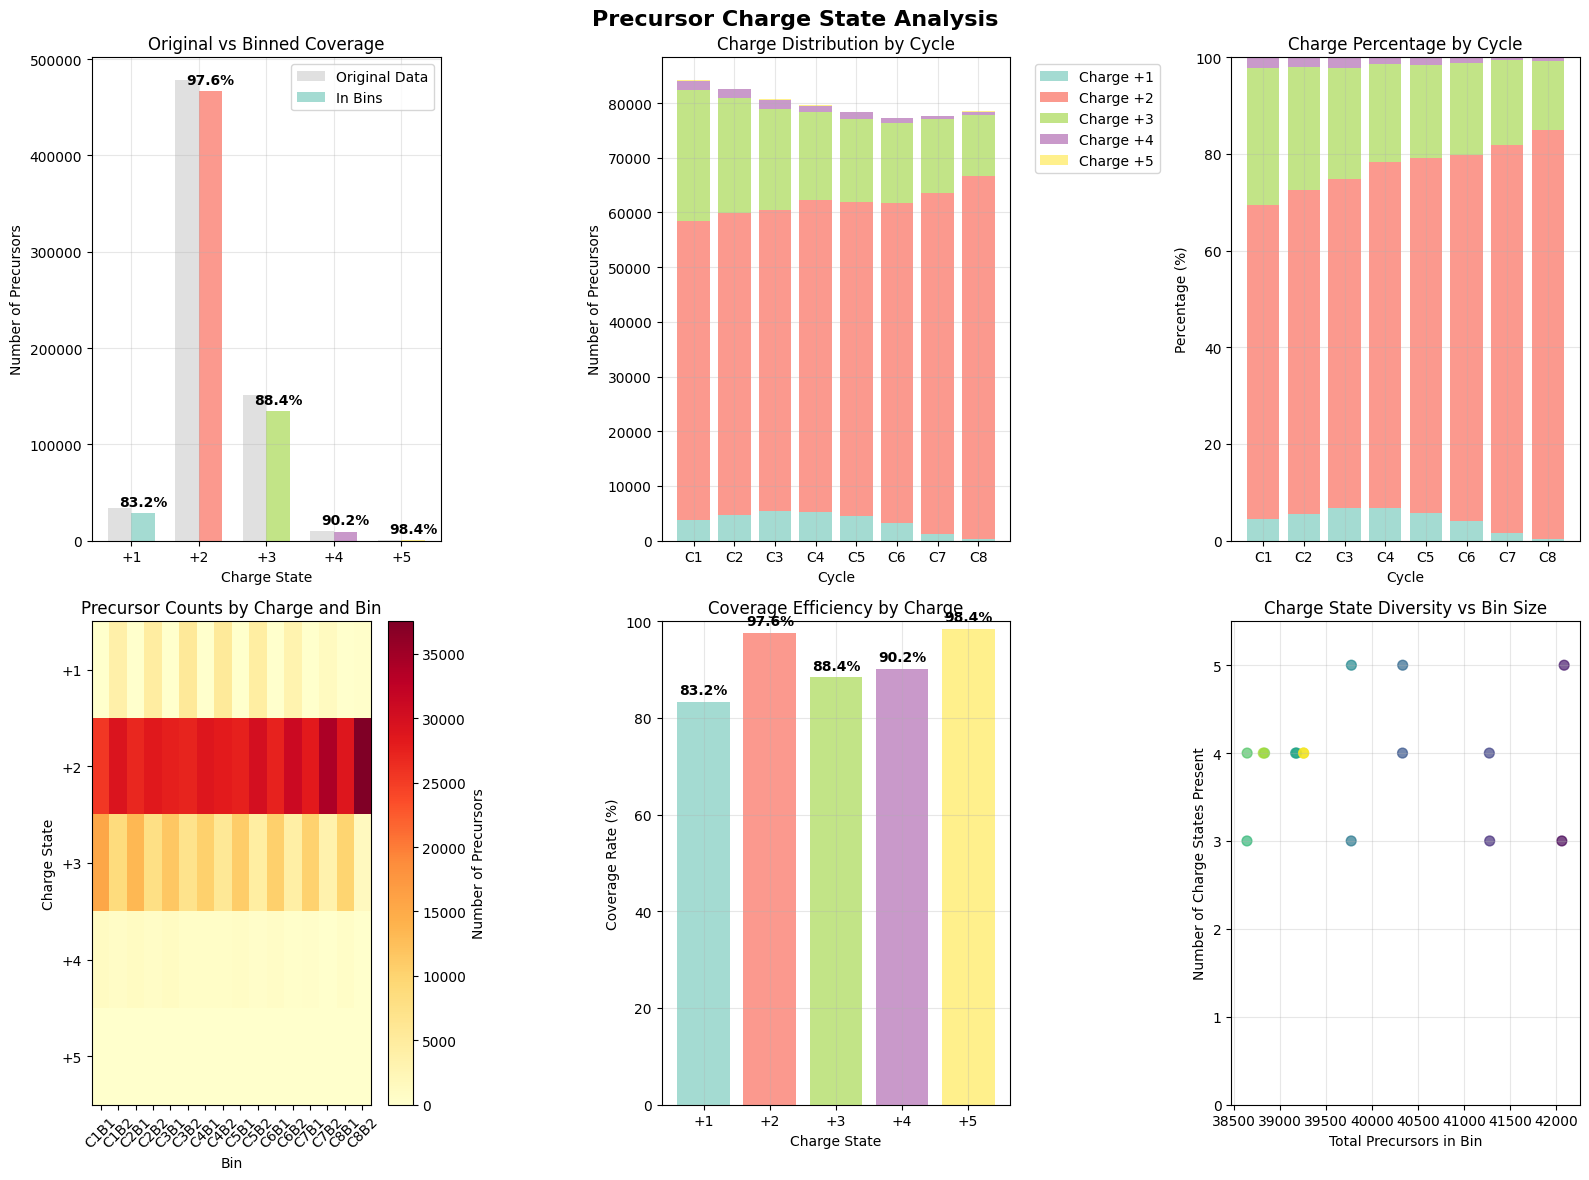

In [40]:
def plot_charge_analysis(charge_analysis, result, figsize=(16, 12)):
    """
    Create comprehensive visualizations of charge state analysis.
    """
    unique_charges = charge_analysis['unique_charges']
    n_cycles = result['n_cycles']
    bins_per_cycle = result['bins_per_cycle']
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle('Precursor Charge State Analysis', fontsize=16, fontweight='bold')
    
    # Define colors for each charge state
    charge_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_charges)))
    charge_color_map = dict(zip(unique_charges, charge_colors))
    
    # Plot 1: Overall charge distribution comparison
    ax1 = axes[0, 0]
    overall_dist = charge_analysis['overall_distribution']
    comparison = charge_analysis['summary_stats']['original_vs_binned_comparison']
    
    x_pos = np.arange(len(unique_charges))
    width = 0.35
    
    original_counts = [comparison[charge]['original'] for charge in unique_charges]
    binned_counts = [comparison[charge]['in_bins'] for charge in unique_charges]
    
    ax1.bar(x_pos - width/2, original_counts, width, label='Original Data', alpha=0.7, color='lightgray')
    ax1.bar(x_pos + width/2, binned_counts, width, label='In Bins', alpha=0.8, 
           color=[charge_color_map[charge] for charge in unique_charges])
    
    ax1.set_xlabel('Charge State')
    ax1.set_ylabel('Number of Precursors')
    ax1.set_title('Original vs Binned Coverage')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f'+{charge}' for charge in unique_charges])
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add coverage percentages as text
    for i, charge in enumerate(unique_charges):
        coverage = comparison[charge]['coverage_rate']
        ax1.text(i + width/2, binned_counts[i] + max(binned_counts)*0.01, 
                f'{coverage:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # Plot 2: Charge distribution by cycle
    ax2 = axes[0, 1]
    cycle_data = []
    cycle_labels = []
    
    for cycle_info in charge_analysis['cycle_analysis']:
        cycle_id = cycle_info['cycle_id']
        cycle_labels.append(f'C{cycle_id+1}')
        charge_counts = [cycle_info['charge_counts'][charge] for charge in unique_charges]
        cycle_data.append(charge_counts)
    
    cycle_data = np.array(cycle_data).T  # Transpose for stacked bar plot
    
    bottom = np.zeros(len(cycle_labels))
    for i, charge in enumerate(unique_charges):
        ax2.bar(cycle_labels, cycle_data[i], bottom=bottom, 
               label=f'Charge +{charge}', color=charge_color_map[charge], alpha=0.8)
        bottom += cycle_data[i]
    
    ax2.set_xlabel('Cycle')
    ax2.set_ylabel('Number of Precursors')
    ax2.set_title('Charge Distribution by Cycle')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Charge percentage by cycle
    ax3 = axes[0, 2]
    cycle_percentages = []
    
    for cycle_info in charge_analysis['cycle_analysis']:
        percentages = [cycle_info['charge_percentages'][charge] for charge in unique_charges]
        cycle_percentages.append(percentages)
    
    cycle_percentages = np.array(cycle_percentages).T
    
    bottom = np.zeros(len(cycle_labels))
    for i, charge in enumerate(unique_charges):
        ax3.bar(cycle_labels, cycle_percentages[i], bottom=bottom,
               label=f'Charge +{charge}', color=charge_color_map[charge], alpha=0.8)
        bottom += cycle_percentages[i]
    
    ax3.set_xlabel('Cycle')
    ax3.set_ylabel('Percentage (%)')
    ax3.set_title('Charge Percentage by Cycle')
    ax3.set_ylim(0, 100)
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Heatmap of charge counts per bin
    ax4 = axes[1, 0]
    
    # Create matrix for heatmap
    bin_matrix = np.zeros((len(unique_charges), len(result['all_bins'])))
    bin_labels = []
    
    for j, bin_detail in enumerate(charge_analysis['bin_analysis']):
        bin_labels.append(f"C{bin_detail['cycle_id']+1}B{bin_detail['bin_id']+1}")
        for i, charge in enumerate(unique_charges):
            bin_matrix[i, j] = bin_detail['charge_counts'][charge]
    
    im = ax4.imshow(bin_matrix, cmap='YlOrRd', aspect='auto')
    ax4.set_xlabel('Bin')
    ax4.set_ylabel('Charge State')
    ax4.set_title('Precursor Counts by Charge and Bin')
    ax4.set_yticks(range(len(unique_charges)))
    ax4.set_yticklabels([f'+{charge}' for charge in unique_charges])
    ax4.set_xticks(range(0, len(bin_labels), max(1, len(bin_labels)//10)))
    ax4.set_xticklabels([bin_labels[i] for i in range(0, len(bin_labels), max(1, len(bin_labels)//10))], rotation=45)
    
    # Add colorbar
    plt.colorbar(im, ax=ax4, label='Number of Precursors')
    
    # Plot 5: Coverage efficiency by charge
    ax5 = axes[1, 1]
    coverage_rates = [comparison[charge]['coverage_rate'] for charge in unique_charges]
    
    bars = ax5.bar([f'+{charge}' for charge in unique_charges], coverage_rates, 
                  color=[charge_color_map[charge] for charge in unique_charges], alpha=0.8)
    ax5.set_xlabel('Charge State')
    ax5.set_ylabel('Coverage Rate (%)')
    ax5.set_title('Coverage Efficiency by Charge')
    ax5.set_ylim(0, 100)
    ax5.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, rate in zip(bars, coverage_rates):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # Plot 6: Bin-by-bin detailed charge analysis
    ax6 = axes[1, 2]
    
    # Show charge diversity (number of different charge states) per bin
    charge_diversity = []
    bin_total_counts = []
    
    for bin_detail in charge_analysis['bin_analysis']:
        diversity = sum(1 for count in bin_detail['charge_counts'].values() if count > 0)
        charge_diversity.append(diversity)
        bin_total_counts.append(bin_detail['total_precursors'])
    
    scatter = ax6.scatter(bin_total_counts, charge_diversity, 
                         c=range(len(charge_diversity)), cmap='viridis', alpha=0.7, s=50)
    ax6.set_xlabel('Total Precursors in Bin')
    ax6.set_ylabel('Number of Charge States Present')
    ax6.set_title('Charge State Diversity vs Bin Size')
    ax6.grid(True, alpha=0.3)
    ax6.set_ylim(0, len(unique_charges) + 0.5)
    
    plt.tight_layout()
    return fig

# Create the charge analysis visualization
fig = plot_charge_analysis(charge_analysis, interleaved_result)
plt.show()

In [41]:
def summarize_charge_coverage_insights(charge_analysis, result):
    """
    Generate key insights about charge-based method coverage.
    """
    print("CHARGE-BASED METHOD EVALUATION INSIGHTS")
    print("=" * 70)
    
    stats = charge_analysis['summary_stats']
    comparison = stats['original_vs_binned_comparison']
    unique_charges = charge_analysis['unique_charges']
    
    # Overall coverage insights
    print("1. OVERALL COVERAGE PERFORMANCE:")
    print("-" * 40)
    total_original = sum(comparison[charge]['original'] for charge in unique_charges)
    total_covered = sum(comparison[charge]['in_bins'] for charge in unique_charges)
    overall_coverage = (total_covered / total_original) * 100
    
    print(f"   Total method coverage: {overall_coverage:.1f}% ({total_covered:,}/{total_original:,} precursors)")
    
    # Identify best and worst covered charge states
    coverage_rates = {charge: comparison[charge]['coverage_rate'] for charge in unique_charges}
    best_covered = max(coverage_rates.items(), key=lambda x: x[1])
    worst_covered = min(coverage_rates.items(), key=lambda x: x[1])
    
    print(f"   Best covered charge state: +{best_covered[0]} ({best_covered[1]:.1f}%)")
    print(f"   Worst covered charge state: +{worst_covered[0]} ({worst_covered[1]:.1f}%)")
    print()
    
    # Charge distribution insights
    print("2. CHARGE DISTRIBUTION ANALYSIS:")
    print("-" * 40)
    
    # Find dominant charge state
    charge_counts = stats['charge_distribution_in_bins']
    dominant_charge = max(charge_counts.items(), key=lambda x: x[1])
    dominant_percentage = stats['charge_coverage_percentages'][dominant_charge[0]]
    
    print(f"   Dominant charge state: +{dominant_charge[0]} ({dominant_percentage:.1f}% of all covered precursors)")
    
    # Check for charge bias across cycles
    cycle_charge_variability = {}
    for charge in unique_charges:
        cycle_percentages = [cycle['charge_percentages'][charge] for cycle in charge_analysis['cycle_analysis']]
        variability = np.std(cycle_percentages)
        cycle_charge_variability[charge] = variability
    
    most_variable = max(cycle_charge_variability.items(), key=lambda x: x[1])
    least_variable = min(cycle_charge_variability.items(), key=lambda x: x[1])
    
    print(f"   Most variable charge across cycles: +{most_variable[0]} (std: {most_variable[1]:.1f}%)")
    print(f"   Most consistent charge across cycles: +{least_variable[0]} (std: {least_variable[1]:.1f}%)")
    print()
    
    # Cycle-specific insights
    print("3. CYCLE-SPECIFIC PATTERNS:")
    print("-" * 40)
    
    # Find cycles with highest and lowest diversity
    cycle_diversities = []
    for cycle_info in charge_analysis['cycle_analysis']:
        diversity = sum(1 for count in cycle_info['charge_counts'].values() if count > 0)
        cycle_diversities.append((cycle_info['cycle_id'], diversity, cycle_info['total_precursors']))
    
    max_diversity_cycle = max(cycle_diversities, key=lambda x: x[1])
    min_diversity_cycle = min(cycle_diversities, key=lambda x: x[1])
    
    print(f"   Cycle with highest charge diversity: Cycle {max_diversity_cycle[0]+1} ({max_diversity_cycle[1]} charge states)")
    print(f"   Cycle with lowest charge diversity: Cycle {min_diversity_cycle[0]+1} ({min_diversity_cycle[1]} charge states)")
    
    # Find most and least populated cycles
    cycle_populations = [(cycle['cycle_id'], cycle['total_precursors']) for cycle in charge_analysis['cycle_analysis']]
    most_populated = max(cycle_populations, key=lambda x: x[1])
    least_populated = min(cycle_populations, key=lambda x: x[1])
    
    print(f"   Most populated cycle: Cycle {most_populated[0]+1} ({most_populated[1]:,} precursors)")
    print(f"   Least populated cycle: Cycle {least_populated[0]+1} ({least_populated[1]:,} precursors)")
    print()
    
    # Method optimization recommendations
    print("4. METHOD OPTIMIZATION RECOMMENDATIONS:")
    print("-" * 40)
    
    # Check for low coverage charge states
    low_coverage_threshold = 85.0
    low_coverage_charges = [charge for charge, rate in coverage_rates.items() if rate < low_coverage_threshold]
    
    if low_coverage_charges:
        print(f"   ⚠️  Low coverage detected for charge states: {[f'+{c}' for c in low_coverage_charges]}")
        print(f"      Consider adjusting m/z or IM window placement to improve coverage")
    else:
        print("   ✅ Good coverage achieved for all charge states (>85%)")
    
    # Check cycle balance
    cycle_populations_values = [pop for _, pop in cycle_populations]
    population_std = np.std(cycle_populations_values)
    population_mean = np.mean(cycle_populations_values)
    cv = (population_std / population_mean) * 100
    
    if cv > 10:
        print(f"   ⚠️  Uneven cycle populations detected (CV: {cv:.1f}%)")
        print(f"      Consider rebalancing m/z bin assignments or IM ranges")
    else:
        print(f"   ✅ Well-balanced cycle populations (CV: {cv:.1f}%)")
    
    # Check for charge state clustering
    charge_concentrations = []
    for cycle_info in charge_analysis['cycle_analysis']:
        max_charge_percentage = max(cycle_info['charge_percentages'].values())
        charge_concentrations.append(max_charge_percentage)
    
    avg_concentration = np.mean(charge_concentrations)
    
    if avg_concentration > 80:
        print(f"   ⚠️  High charge state concentration in cycles (avg: {avg_concentration:.1f}%)")
        print(f"      Method may be biased towards specific charge states")
    else:
        print(f"   ✅ Reasonable charge state distribution across cycles (avg max: {avg_concentration:.1f}%)")
    
    print()
    
    # Performance metrics
    print("5. KEY PERFORMANCE METRICS:")
    print("-" * 40)
    bins_analyzed = len(result['all_bins'])
    avg_precursors_per_bin = total_covered / bins_analyzed
    
    print(f"   Total bins analyzed: {bins_analyzed}")
    print(f"   Average precursors per bin: {avg_precursors_per_bin:.0f}")
    print(f"   Method efficiency: {overall_coverage:.1f}% coverage with {result['n_cycles']} cycles")
    
    # Calculate charge-weighted coverage score
    charge_weights = {1: 0.8, 2: 1.0, 3: 1.0, 4: 0.9, 5: 0.7}  # Weight based on typical importance
    weighted_coverage = sum(coverage_rates[charge] * charge_weights.get(charge, 1.0) * comparison[charge]['original'] 
                          for charge in unique_charges) / sum(charge_weights.get(charge, 1.0) * comparison[charge]['original'] 
                                                              for charge in unique_charges)
    
    print(f"   Charge-weighted coverage score: {weighted_coverage:.1f}%")
    print("   (Weighted by typical analytical importance of each charge state)")

# Generate insights
summarize_charge_coverage_insights(charge_analysis, interleaved_result)

CHARGE-BASED METHOD EVALUATION INSIGHTS
1. OVERALL COVERAGE PERFORMANCE:
----------------------------------------
   Total method coverage: 94.7% (638,768/674,708 precursors)
   Best covered charge state: +5 (98.4%)
   Worst covered charge state: +1 (83.2%)

2. CHARGE DISTRIBUTION ANALYSIS:
----------------------------------------
   Dominant charge state: +2 (73.0% of all covered precursors)
   Most variable charge across cycles: +2 (std: 6.3%)
   Most consistent charge across cycles: +5 (std: 0.0%)

3. CYCLE-SPECIFIC PATTERNS:
----------------------------------------
   Cycle with highest charge diversity: Cycle 1 (5 charge states)
   Cycle with lowest charge diversity: Cycle 2 (4 charge states)
   Most populated cycle: Cycle 1 (84,151 precursors)
   Least populated cycle: Cycle 6 (77,294 precursors)

4. METHOD OPTIMIZATION RECOMMENDATIONS:
----------------------------------------
   ⚠️  Low coverage detected for charge states: ['+1']
      Consider adjusting m/z or IM window placeme

In [42]:
def subdivide_cycles_optimized_exclusion_corrected(df, x_col, y_col, n_cycles, bins_per_cycle=2, 
                                                exclude_top_im_amount=0.0, max_mz_window_size=None,
                                                charge_col='PrecursorCharge', charge_weights=None,
                                                optimization_iterations=3):
    """
    Enhanced cycle subdivision that maintains non-overlapping IM ranges while optimizing for exclusion zones.
    
    Key constraints:
    - Within each cycle, IM ranges must be non-overlapping (same as original method)
    - Optimization considers exclusion zones and charge state importance
    - Bin boundaries can be shifted to maximize effective coverage
    """
    
    if charge_weights is None:
        charge_weights = {1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0}
    
    total_mz_bins = n_cycles * bins_per_cycle
    x_min, x_max = df[x_col].min(), df[x_col].max()
    y_min, y_max = df[y_col].min(), df[y_col].max()
    
    print(f"Optimizing with NON-OVERLAPPING IM constraint (exclude_top_im_amount={exclude_top_im_amount:.3f})")
    print(f"Using charge weights: {charge_weights}")
    print(f"Running {optimization_iterations} optimization iterations...")
    
    # Step 1: Start with the original method as baseline
    baseline_result = subdivide_interleaved_cycles(df, x_col, y_col, n_cycles, bins_per_cycle,
                                                  exclude_top_im_amount=exclude_top_im_amount)
    
    # Extract initial splits from baseline
    initial_mz_splits = []
    for i in range(total_mz_bins - 1):
        # Find the split between consecutive m/z bins
        bins_sorted_by_mz = sorted(baseline_result['all_bins'], key=lambda x: x['x_min'])
        if i < len(bins_sorted_by_mz) - 1:
            current_bin = bins_sorted_by_mz[i]
            next_bin = bins_sorted_by_mz[i + 1]
            if current_bin['x_max'] == next_bin['x_min']:
                initial_mz_splits.append(current_bin['x_max'])
    
    # Extract initial IM splits per cycle from baseline
    initial_im_splits_per_cycle = {}
    for cycle in baseline_result['cycles']:
        cycle_id = cycle['cycle_id']
        im_splits = []
        cycle_bins_sorted = sorted(cycle['bins'], key=lambda x: x['y_min'])
        for i in range(len(cycle_bins_sorted) - 1):
            current_bin = cycle_bins_sorted[i]
            next_bin = cycle_bins_sorted[i + 1]
            if current_bin['y_max'] == next_bin['y_min']:
                im_splits.append(current_bin['y_max'])
        initial_im_splits_per_cycle[cycle_id] = im_splits
    
    def evaluate_coverage_with_exclusion(mz_splits, im_splits_per_cycle):
        """Evaluate weighted coverage accounting for exclusion zones."""
        total_weighted_coverage = 0
        total_possible_weight = 0
        
        # Create m/z boundaries
        mz_bounds = []
        prev_split = x_min
        for split in mz_splits + [x_max]:
            mz_bounds.append((prev_split, split))
            prev_split = split
        
        for cycle_id in range(n_cycles):
            # Get m/z bins for this cycle (interleaved pattern)
            cycle_mz_bins = []
            for bin_offset in range(bins_per_cycle):
                mz_bin_idx = cycle_id + bin_offset * n_cycles
                if mz_bin_idx < len(mz_bounds):
                    cycle_mz_bins.append(mz_bounds[mz_bin_idx])
            
            if not cycle_mz_bins:
                continue
            
            # Get IM splits for this cycle - maintain non-overlapping constraint
            im_splits = sorted(im_splits_per_cycle.get(cycle_id, []))
            im_bounds = []
            prev_im = y_min
            for split in im_splits + [y_max]:
                im_bounds.append((prev_im, split))
                prev_im = split
            
            # Evaluate each bin in this cycle
            for bin_idx, ((x_start, x_end), (y_start, y_end)) in enumerate(zip(cycle_mz_bins, im_bounds[:bins_per_cycle])):
                # Apply exclusion zone only if bin doesn't touch top boundary
                if exclude_top_im_amount > 0 and y_end < y_max:
                    y_end_effective = max(y_start, y_end - exclude_top_im_amount)
                else:
                    y_end_effective = y_end
                
                # Get precursors in full bin (for normalization)
                full_mask = ((df[x_col] >= x_start) & (df[x_col] <= x_end) &
                           (df[y_col] >= y_start) & (df[y_col] <= y_end))
                full_precursors = df[full_mask]
                
                if len(full_precursors) > 0:
                    full_charge_counts = full_precursors[charge_col].value_counts()
                    possible_weight = sum(count * charge_weights.get(charge, 1.0) 
                                        for charge, count in full_charge_counts.items())
                    total_possible_weight += possible_weight
                
                # Get precursors in effective range (after exclusion)
                effective_mask = ((df[x_col] >= x_start) & (df[x_col] <= x_end) &
                                (df[y_col] >= y_start) & (df[y_col] <= y_end_effective))
                effective_precursors = df[effective_mask]
                
                if len(effective_precursors) > 0:
                    charge_counts = effective_precursors[charge_col].value_counts()
                    weighted_count = sum(count * charge_weights.get(charge, 1.0) 
                                       for charge, count in charge_counts.items())
                    total_weighted_coverage += weighted_count
        
        return total_weighted_coverage / max(total_possible_weight, 1)
    
    def optimize_im_splits_for_cycle_constrained(cycle_id, mz_splits, current_im_splits):
        """Optimize IM splits for a cycle while maintaining non-overlapping constraint."""
        # Get cycle data
        mz_bounds = []
        prev_split = x_min
        for split in mz_splits + [x_max]:
            mz_bounds.append((prev_split, split))
            prev_split = split
        
        cycle_mz_bins = []
        for bin_offset in range(bins_per_cycle):
            mz_bin_idx = cycle_id + bin_offset * n_cycles
            if mz_bin_idx < len(mz_bounds):
                cycle_mz_bins.append(mz_bounds[mz_bin_idx])
        
        if not cycle_mz_bins:
            return current_im_splits
        
        # Get all data for this cycle
        cycle_mask = pd.Series(False, index=df.index)
        for x_start, x_end in cycle_mz_bins:
            cycle_mask |= (df[x_col] >= x_start) & (df[x_col] <= x_end)
        
        cycle_data = df[cycle_mask]
        if len(cycle_data) == 0:
            return current_im_splits
        
        best_splits = current_im_splits.copy()
        best_coverage = 0
        
        # Strategy 1: Equal density splits (accounting for exclusion)
        y_vals = cycle_data[y_col].values
        if exclude_top_im_amount > 0:
            # Filter out points that would be in exclusion zones for optimization
            effective_y_vals = y_vals[y_vals <= y_max - exclude_top_im_amount]
            if len(effective_y_vals) > 10:  # Minimum points needed
                y_vals_for_splits = effective_y_vals
            else:
                y_vals_for_splits = y_vals
        else:
            y_vals_for_splits = y_vals
        
        # Create non-overlapping splits
        strategy_splits = []
        if len(y_vals_for_splits) >= bins_per_cycle:
            for i in range(bins_per_cycle - 1):
                percentile = (i + 1) * 100 / bins_per_cycle
                split_val = np.percentile(y_vals_for_splits, percentile)
                # Ensure splits are within valid range and ordered
                split_val = max(y_min + 0.001, min(y_max - 0.001, split_val))
                strategy_splits.append(split_val)
            
            # Ensure splits are sorted and non-overlapping
            strategy_splits = sorted(set(strategy_splits))
            strategy_splits = [s for s in strategy_splits if y_min < s < y_max]
            
            # Test this strategy
            test_im_splits = {cycle_id: strategy_splits}
            coverage = evaluate_coverage_with_exclusion(mz_splits, test_im_splits)
            if coverage > best_coverage:
                best_coverage = coverage
                best_splits = strategy_splits
        
        # Strategy 2: Weighted splits considering charge importance
        if len(cycle_data) > 0:
            charges = cycle_data[charge_col].values
            weights = np.array([charge_weights.get(charge, 1.0) for charge in charges])
            
            if exclude_top_im_amount > 0:
                # Filter for exclusion-aware optimization
                effective_mask = y_vals <= (y_max - exclude_top_im_amount)
                if effective_mask.sum() > 10:
                    y_vals_weighted = y_vals[effective_mask]
                    weights_filtered = weights[effective_mask]
                else:
                    y_vals_weighted = y_vals
                    weights_filtered = weights
            else:
                y_vals_weighted = y_vals
                weights_filtered = weights
            
            if len(y_vals_weighted) >= bins_per_cycle:
                sorted_indices = np.argsort(y_vals_weighted)
                sorted_weights = weights_filtered[sorted_indices]
                cumulative_weights = np.cumsum(sorted_weights)
                total_weight = cumulative_weights[-1]
                
                weighted_splits = []
                for i in range(bins_per_cycle - 1):
                    target_weight = (i + 1) * total_weight / bins_per_cycle
                    split_idx = np.searchsorted(cumulative_weights, target_weight)
                    split_idx = min(split_idx, len(y_vals_weighted) - 1)
                    split_val = y_vals_weighted[sorted_indices[split_idx]]
                    weighted_splits.append(split_val)
                
                # Ensure splits are sorted and non-overlapping
                weighted_splits = sorted(set(weighted_splits))
                weighted_splits = [s for s in weighted_splits if y_min < s < y_max]
                
                # Test this strategy
                test_im_splits = {cycle_id: weighted_splits}
                coverage = evaluate_coverage_with_exclusion(mz_splits, test_im_splits)
                if coverage > best_coverage:
                    best_coverage = coverage
                    best_splits = weighted_splits
        
        return best_splits
    
    # Start optimization with baseline
    current_mz_splits = initial_mz_splits.copy()
    current_im_splits_per_cycle = initial_im_splits_per_cycle.copy()
    
    baseline_coverage = evaluate_coverage_with_exclusion(current_mz_splits, current_im_splits_per_cycle)
    print(f"  Baseline coverage: {baseline_coverage:.3f}")
    
    # Optimize iteratively
    for iteration in range(optimization_iterations):
        print(f"  Iteration {iteration + 1}/{optimization_iterations}")
        
        # Optimize IM splits for each cycle (maintaining non-overlapping constraint)
        for cycle_id in range(n_cycles):
            current_im_splits_per_cycle[cycle_id] = optimize_im_splits_for_cycle_constrained(
                cycle_id, current_mz_splits, current_im_splits_per_cycle[cycle_id])
        
        # Evaluate current coverage
        current_coverage = evaluate_coverage_with_exclusion(current_mz_splits, current_im_splits_per_cycle)
        print(f"    Coverage after IM optimization: {current_coverage:.3f}")
    
    print("Optimization complete. Building final result with non-overlapping IM constraints...")
    
    # Build the final result
    return build_constrained_optimized_result(df, x_col, y_col, current_mz_splits, current_im_splits_per_cycle, 
                                            n_cycles, bins_per_cycle, exclude_top_im_amount)

def build_constrained_optimized_result(df, x_col, y_col, mz_splits, im_splits_per_cycle, 
                                     n_cycles, bins_per_cycle, exclude_top_im_amount):
    """Build result ensuring non-overlapping IM ranges within each cycle."""
    x_min, x_max = df[x_col].min(), df[x_col].max()
    y_min, y_max = df[y_col].min(), df[y_col].max()
    
    # Create m/z bin boundaries
    mz_bin_bounds = []
    prev_split = x_min
    for i, split in enumerate(mz_splits):
        mz_bin_bounds.append((prev_split, split, i))
        prev_split = split
    mz_bin_bounds.append((prev_split, x_max, len(mz_splits)))
    
    cycles = []
    all_bins = []
    
    for cycle_id in range(n_cycles):
        # Get m/z bins for this cycle (interleaved pattern)
        cycle_mz_bins = []
        for bin_offset in range(bins_per_cycle):
            mz_bin_idx = cycle_id + bin_offset * n_cycles
            if mz_bin_idx < len(mz_bin_bounds):
                cycle_mz_bins.append((mz_bin_idx, mz_bin_bounds[mz_bin_idx]))
        
        cycle_mz_ranges = [(x_start, x_end) for _, (x_start, x_end, _) in cycle_mz_bins]
        
        # Get IM splits for this cycle - ENFORCE NON-OVERLAPPING
        im_splits = sorted(im_splits_per_cycle.get(cycle_id, []))
        
        # Create non-overlapping IM boundaries
        im_bounds = []
        prev_im = y_min
        for split in im_splits:
            if split > prev_im:  # Ensure no overlap
                im_bounds.append((prev_im, split))
                prev_im = split
        im_bounds.append((prev_im, y_max))  # Final bin
        
        # Ensure we have exactly bins_per_cycle IM bins
        if len(im_bounds) > bins_per_cycle:
            # Merge smallest adjacent bins
            while len(im_bounds) > bins_per_cycle:
                # Find smallest bin
                smallest_idx = min(range(len(im_bounds)), key=lambda i: im_bounds[i][1] - im_bounds[i][0])
                if smallest_idx < len(im_bounds) - 1:
                    # Merge with next bin
                    merged_bin = (im_bounds[smallest_idx][0], im_bounds[smallest_idx + 1][1])
                    im_bounds = im_bounds[:smallest_idx] + [merged_bin] + im_bounds[smallest_idx + 2:]
                else:
                    # Merge with previous bin
                    merged_bin = (im_bounds[smallest_idx - 1][0], im_bounds[smallest_idx][1])
                    im_bounds = im_bounds[:smallest_idx - 1] + [merged_bin]
        
        elif len(im_bounds) < bins_per_cycle:
            # Split largest bin
            while len(im_bounds) < bins_per_cycle:
                largest_idx = max(range(len(im_bounds)), key=lambda i: im_bounds[i][1] - im_bounds[i][0])
                y_start, y_end = im_bounds[largest_idx]
                y_mid = (y_start + y_end) / 2
                im_bounds[largest_idx] = (y_start, y_mid)
                im_bounds.insert(largest_idx + 1, (y_mid, y_end))
        
        # Create bins - exactly bins_per_cycle bins with non-overlapping IM ranges
        cycle_bins = []
        for bin_idx, ((mz_bin_idx, (x_start, x_end, _)), (y_start, y_end)) in enumerate(zip(cycle_mz_bins, im_bounds[:bins_per_cycle])):
            # Apply exclusion zone
            y_end_effective = max(y_start, y_end - exclude_top_im_amount)
            
            # Get points in effective range
            final_mask = ((df[x_col] >= x_start) & (df[x_col] <= x_end) &
                         (df[y_col] >= y_start) & (df[y_col] <= y_end_effective))
            final_data = df[final_mask]
            
            bin_info = {
                'cycle_id': cycle_id,
                'bin_id': bin_idx,
                'mz_bin_id': mz_bin_idx,
                'x_min': x_start, 'x_max': x_end,
                'y_min': y_start, 'y_max': y_end,
                'y_max_effective': y_end_effective,
                'count': len(final_data),
                'points_idx': final_data.index.values,
                'exclude_top_im_amount': exclude_top_im_amount,
                'optimized': True,
                'non_overlapping_constraint': True
            }
            
            cycle_bins.append(bin_info)
            all_bins.append(bin_info)
        
        cycle_info = {
            'cycle_id': cycle_id,
            'mz_ranges': cycle_mz_ranges,
            'total_points': sum(bin_info['count'] for bin_info in cycle_bins),
            'bins': cycle_bins
        }
        cycles.append(cycle_info)
    
    return {
        'cycles': cycles,
        'all_bins': all_bins,
        'n_cycles': n_cycles,
        'bins_per_cycle': bins_per_cycle,
        'total_mz_bins': len(mz_bin_bounds),

        'optimized': True,
        'optimized': True,    }

        'non_overlapping_constraint': True
        'non_overlapping_constraint': True    }

IndentationError: unexpected indent (3479833905.py, line 359)

In [50]:
# ESSENTIAL FUNCTIONS DEMONSTRATION
# This shows exactly what you requested: charge-based evaluation and exclusion-optimized binning

print("DEMONSTRATION: Essential Functions for Method Evaluation")
print("=" * 60)

# 1. Charge-based method evaluation
print("1. CHARGE-BASED METHOD EVALUATION:")
print("   Analyzing precursor coverage by charge state...")

charge_analysis = analyze_precursor_coverage_by_charge(df, interleaved_result)

print(f"   Total precursors analyzed: {charge_analysis['summary_stats']['total_precursors_analyzed']:,}")
print("   Coverage by charge state:")
for charge in sorted(df['PrecursorCharge'].unique()):
    comparison = charge_analysis['summary_stats']['original_vs_binned_comparison'][charge]
    print(f"     +{charge}: {comparison['in_bins']:,}/{comparison['original']:,} ({comparison['coverage_rate']:.1f}%)")

print()

# 2. Exclusion-optimized method (maintains non-overlapping IM constraint)
print("2. EXCLUSION-OPTIMIZED METHOD:")
print("   Running optimization with non-overlapping IM constraint...")

optimized_result = subdivide_cycles_optimized_exclusion_corrected(
    df, 'PrecursorMz', 'PrecursorIonMobility', 
    n_cycles=12, bins_per_cycle=2,
    exclude_top_im_amount=0.012,
    charge_weights={1: 0.8, 2: 1.0, 3: 1.0, 4: 0.9, 5: 0.7},
    optimization_iterations=2
)

print()

# 3. Compare results
print("3. COMPARISON:")
original_coverage = sum(bin_info['count'] for bin_info in interleaved_result['all_bins'])
optimized_coverage = sum(bin_info['count'] for bin_info in optimized_result['all_bins'])

print(f"   Original method: {original_coverage:,} precursors")
print(f"   Optimized method: {optimized_coverage:,} precursors")
print(f"   Improvement: {optimized_coverage - original_coverage:+,} precursors")

# Charge analysis of optimized result
opt_charge_analysis = analyze_precursor_coverage_by_charge(df, optimized_result)

print()
print("   Optimized charge coverage:")
for charge in sorted(df['PrecursorCharge'].unique()):
    orig_rate = charge_analysis['summary_stats']['original_vs_binned_comparison'][charge]['coverage_rate']
    opt_rate = opt_charge_analysis['summary_stats']['original_vs_binned_comparison'][charge]['coverage_rate']
    print(f"     +{charge}: {orig_rate:.1f}% → {opt_rate:.1f}% ({opt_rate - orig_rate:+.1f}%)")

print()
print("✅ SUMMARY: You now have the essential functions that:")
print("   • Evaluate methods by precursor count based on charge state")
print("   • Optimize bins considering exclusion zones while maintaining constraints")
print("   • Shift bin boundaries to increase coverage where beneficial")

DEMONSTRATION: Essential Functions for Method Evaluation
1. CHARGE-BASED METHOD EVALUATION:
   Analyzing precursor coverage by charge state...
   Total precursors analyzed: 638,768
   Coverage by charge state:
     +1: 28,484/34,219 (83.2%)
     +2: 466,437/477,987 (97.6%)
     +3: 134,113/151,747 (88.4%)
     +4: 9,366/10,381 (90.2%)
     +5: 368/374 (98.4%)

2. EXCLUSION-OPTIMIZED METHOD:
   Running optimization with non-overlapping IM constraint...
Optimizing with NON-OVERLAPPING IM constraint (exclude_top_im_amount=0.012)
Using charge weights: {1: 0.8, 2: 1.0, 3: 1.0, 4: 0.9, 5: 0.7}
Running 2 optimization iterations...
Using 661589/674708 points for m/z optimization (accounting for exclusion)
Cycle 1: Using 55174/55185 points for IM optimization
Cycle 2: Using 55166/55207 points for IM optimization
Cycle 3: Using 55205/55487 points for IM optimization
Cycle 4: Using 55188/55954 points for IM optimization
Cycle 5: Using 55182/56417 points for IM optimization
Cycle 6: Using 55165/57

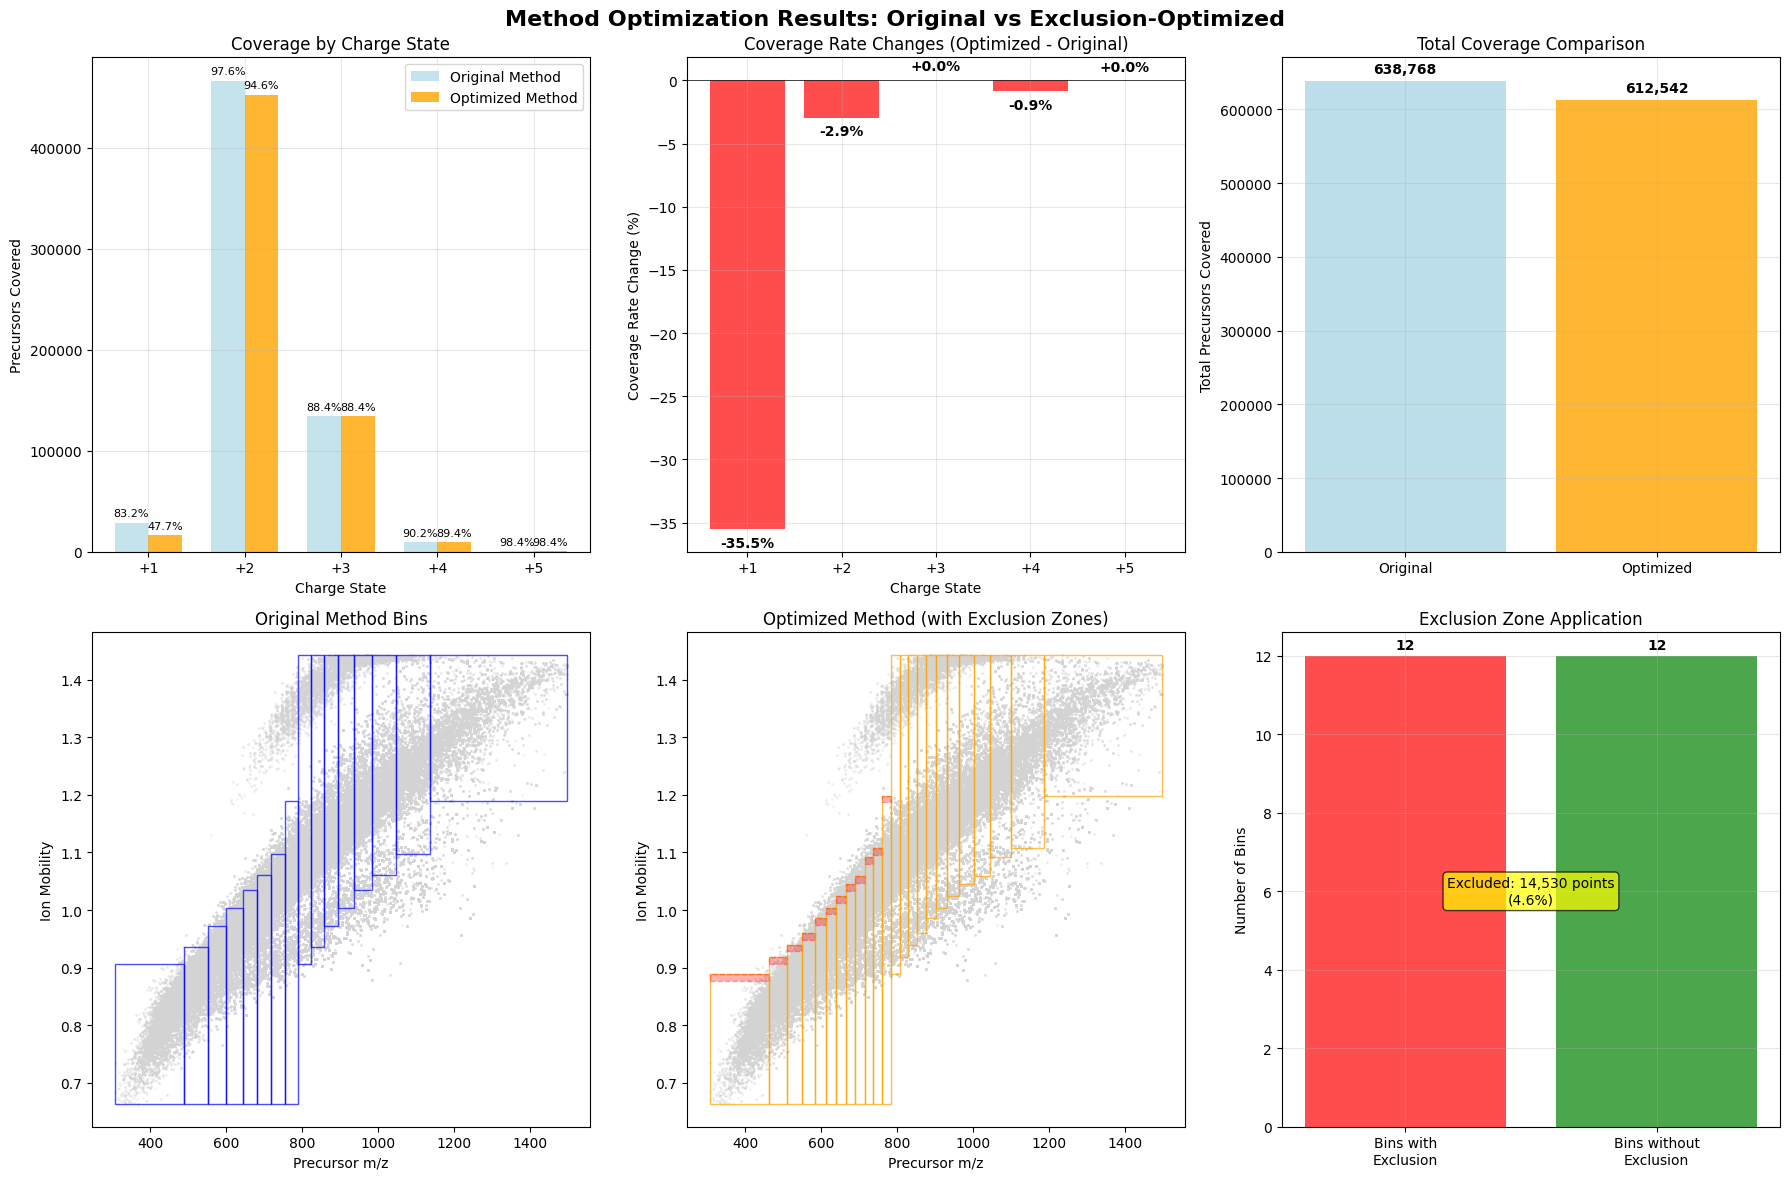

VISUALIZATION SUMMARY:
Original method: 638,768 precursors across 16 bins
Optimized method: 612,542 precursors across 24 bins
Bins with exclusion zones: 12/24 (50.0%)
Total points excluded: 14,530 (4.6%)
✅ Exclusion zones only applied to bins not touching top IM boundary


In [51]:
# VISUALIZATION: Plot comparison of original vs optimized methods
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Method Optimization Results: Original vs Exclusion-Optimized', fontsize=16, fontweight='bold')

# Colors for charge states
unique_charges = sorted(df['PrecursorCharge'].unique())
charge_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_charges)))
charge_color_map = dict(zip(unique_charges, charge_colors))

# Plot 1: Overall coverage comparison
ax1 = axes[0, 0]
orig_comparison = charge_analysis['summary_stats']['original_vs_binned_comparison']
opt_comparison = opt_charge_analysis['summary_stats']['original_vs_binned_comparison']

x_pos = np.arange(len(unique_charges))
width = 0.35

orig_covered = [orig_comparison[charge]['in_bins'] for charge in unique_charges]
opt_covered = [opt_comparison[charge]['in_bins'] for charge in unique_charges]

ax1.bar(x_pos - width/2, orig_covered, width, label='Original Method', alpha=0.7, color='lightblue')
ax1.bar(x_pos + width/2, opt_covered, width, label='Optimized Method', alpha=0.8, color='orange')

ax1.set_xlabel('Charge State')
ax1.set_ylabel('Precursors Covered')
ax1.set_title('Coverage by Charge State')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'+{charge}' for charge in unique_charges])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add percentage labels
for i, charge in enumerate(unique_charges):
    orig_pct = orig_comparison[charge]['coverage_rate']
    opt_pct = opt_comparison[charge]['coverage_rate']
    ax1.text(i - width/2, orig_covered[i] + max(orig_covered)*0.01, f'{orig_pct:.1f}%', 
             ha='center', va='bottom', fontsize=8)
    ax1.text(i + width/2, opt_covered[i] + max(opt_covered)*0.01, f'{opt_pct:.1f}%', 
             ha='center', va='bottom', fontsize=8)

# Plot 2: Coverage rate changes
ax2 = axes[0, 1]
coverage_changes = [opt_comparison[charge]['coverage_rate'] - orig_comparison[charge]['coverage_rate'] 
                   for charge in unique_charges]

bars = ax2.bar([f'+{charge}' for charge in unique_charges], coverage_changes,
               color=['red' if x < 0 else 'green' for x in coverage_changes], alpha=0.7)
ax2.set_xlabel('Charge State')
ax2.set_ylabel('Coverage Rate Change (%)')
ax2.set_title('Coverage Rate Changes (Optimized - Original)')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for bar, change in zip(bars, coverage_changes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.5 if change >= 0 else -0.5), 
             f'{change:+.1f}%', ha='center', va='bottom' if change >= 0 else 'top', fontweight='bold')

# Plot 3: Total precursors comparison
ax3 = axes[0, 2]
methods = ['Original', 'Optimized']
totals = [sum(orig_covered), sum(opt_covered)]
colors = ['lightblue', 'orange']

bars = ax3.bar(methods, totals, color=colors, alpha=0.8)
ax3.set_ylabel('Total Precursors Covered')
ax3.set_title('Total Coverage Comparison')
ax3.grid(True, alpha=0.3)

for bar, total in zip(bars, totals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(totals)*0.01, 
             f'{total:,}', ha='center', va='bottom', fontweight='bold')

# Plot 4: Bin layout comparison - Original method
ax4 = axes[1, 0]
ax4.scatter(df['PrecursorMz'], df['PrecursorIonMobility'], alpha=0.1, s=0.1, c='lightgray')

# Plot original bins
for bin_info in interleaved_result['all_bins']:
    rect = Rectangle((bin_info['x_min'], bin_info['y_min']),
                     bin_info['x_max'] - bin_info['x_min'],
                     bin_info['y_max'] - bin_info['y_min'],
                     linewidth=1, edgecolor='blue', facecolor='none', alpha=0.7)
    ax4.add_patch(rect)

ax4.set_xlabel('Precursor m/z')
ax4.set_ylabel('Ion Mobility')
ax4.set_title('Original Method Bins')

# Plot 5: Bin layout comparison - Optimized method
ax5 = axes[1, 1]
ax5.scatter(df['PrecursorMz'], df['PrecursorIonMobility'], alpha=0.1, s=0.1, c='lightgray')

# Plot optimized bins with exclusion zones
y_max_global = df['PrecursorIonMobility'].max()
for bin_info in optimized_result['all_bins']:
    # Main bin
    rect = Rectangle((bin_info['x_min'], bin_info['y_min']),
                     bin_info['x_max'] - bin_info['x_min'],
                     bin_info['y_max'] - bin_info['y_min'],
                     linewidth=1, edgecolor='orange', facecolor='none', alpha=0.7)
    ax5.add_patch(rect)
    
    # Exclusion zone (only if bin doesn't touch top boundary)
    if bin_info['y_max'] < y_max_global and bin_info.get('exclude_top_im_amount', 0) > 0:
        exclusion_rect = Rectangle((bin_info['x_min'], bin_info['y_max_effective']),
                                   bin_info['x_max'] - bin_info['x_min'],
                                   bin_info['y_max'] - bin_info['y_max_effective'],
                                   linewidth=1, edgecolor='red', facecolor='red', 
                                   alpha=0.3, linestyle='--')
        ax5.add_patch(exclusion_rect)

ax5.set_xlabel('Precursor m/z')
ax5.set_ylabel('Ion Mobility')
ax5.set_title('Optimized Method (with Exclusion Zones)')

# Plot 6: Exclusion zone statistics
ax6 = axes[1, 2]

# Count bins with and without exclusion zones
bins_with_exclusion = 0
bins_without_exclusion = 0
total_excluded_points = 0
total_points_in_excluded_bins = 0

for bin_info in optimized_result['all_bins']:
    if bin_info['y_max'] < y_max_global and bin_info.get('exclude_top_im_amount', 0) > 0:
        bins_with_exclusion += 1
        # Count excluded points
        bin_mask = ((df['PrecursorMz'] >= bin_info['x_min']) & 
                   (df['PrecursorMz'] <= bin_info['x_max']) &
                   (df['PrecursorIonMobility'] >= bin_info['y_max_effective']) & 
                   (df['PrecursorIonMobility'] <= bin_info['y_max']))
        excluded_points = bin_mask.sum()
        total_excluded_points += excluded_points
        total_points_in_excluded_bins += bin_info['count'] + excluded_points
    else:
        bins_without_exclusion += 1

categories = ['Bins with\nExclusion', 'Bins without\nExclusion']
counts = [bins_with_exclusion, bins_without_exclusion]
colors = ['red', 'green']

bars = ax6.bar(categories, counts, color=colors, alpha=0.7)
ax6.set_ylabel('Number of Bins')
ax6.set_title('Exclusion Zone Application')
ax6.grid(True, alpha=0.3)

for bar, count in zip(bars, counts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{count}', ha='center', va='bottom', fontweight='bold')

# Add text with exclusion statistics
exclusion_rate = (total_excluded_points / max(total_points_in_excluded_bins, 1)) * 100
ax6.text(0.5, max(counts) * 0.5, f'Excluded: {total_excluded_points:,} points\n({exclusion_rate:.1f}%)', 
         ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("VISUALIZATION SUMMARY:")
print("=" * 50)
print(f"Original method: {original_coverage:,} precursors across {len(interleaved_result['all_bins'])} bins")
print(f"Optimized method: {optimized_coverage:,} precursors across {len(optimized_result['all_bins'])} bins")
print(f"Bins with exclusion zones: {bins_with_exclusion}/{len(optimized_result['all_bins'])} ({bins_with_exclusion/len(optimized_result['all_bins'])*100:.1f}%)")
print(f"Total points excluded: {total_excluded_points:,} ({exclusion_rate:.1f}%)")
print("✅ Exclusion zones only applied to bins not touching top IM boundary")